<a href="https://colab.research.google.com/github/Antonyus1204/Proyecto_grupal_BIO218./blob/Proyecto-ConchaNegra-BIO218/Proyecto_grupal_BIO218.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
# ============================================================
# CELDA 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================
# NumPy permite generar números aleatorios con distribuciones estadísticas
# (como la normal) y hacer cálculos numéricos sobre conjuntos de datos completos.
import numpy as np

# Pandas se utiliza para organizar los datos en un DataFrame.
import pandas as pd

# Matplotlib se utiliza para construir visualizaciones científicas.
import matplotlib.pyplot as plt

# Confirmamos que el entorno quedó preparado.
print("Entorno de análisis preparado correctamente.")

Entorno de análisis preparado correctamente.


In [27]:
# ============================================================
# CELDA 2. GENERACIÓN DEL DATASET SIMULADO
# ============================================================
# Fijamos una semilla para que la simulación sea reproducible.
np.random.seed(42)

# Definimos el número de observaciones (individuos simulados).
n = 200

# Simulamos el largo de la concha (cm) con distribución normal.
# Rango ajustado (4.0–7.0 cm) para alinearse con literatura biométrica de referencia.
largo = np.random.normal(loc=5.6, scale=0.8, size=n)
largo = np.clip(largo, 4.0, 7.0)

# Generamos ruido aleatorio para representar variación biológica individual.
ruido = np.random.normal(0, 5.5, n)

# Calculamos el peso a partir de una relación alométrica (no lineal) con el largo.
peso = 1.48 * (largo ** 2.13) + ruido

# Recortamos pesos fuera de un rango biológicamente plausible.
# Rango ampliado (18–95 g) para evitar que muchos valores queden "pegados" al límite.
peso = np.clip(peso, 18, 95)

# Calculamos la circunferencia de la concha, proporcional al largo, con variación propia.
circunferencia = 2.6 * largo + np.random.normal(0, 0.6, n)

# Definimos una función para clasificar la talla comercial según el peso.
def clasificar_talla(p):
    if p < 45:
        return "Pequeña"
    elif p < 65:
        return "Mediana"
    else:
        return "Grande"

talla = [clasificar_talla(p) for p in peso]

df = pd.DataFrame({
    "id": range(1, n+1),
    "largo_cm": largo.round(2),
    "peso_g": peso.round(1),
    "circunferencia_cm": circunferencia.round(2),
    "talla": talla
})

df.to_csv("concha_negra_simulada.csv", index=False)
print("Dataset generado y guardado como concha_negra_simulada.csv")
print("Dimensiones:", df.shape)

Dataset generado y guardado como concha_negra_simulada.csv
Dimensiones: (200, 5)


In [28]:
# ============================================================
# CELDA 3. PRIMERA INSPECCIÓN DEL DATASET
# ============================================================
# head() muestra las primeras cinco observaciones.
display(df.head())

# info() resume tipos de datos y valores no nulos.
df.info()

# describe() genera un resumen estadístico de las variables numéricas.
display(df.describe().round(2))

,id,largo_cm,peso_g,circunferencia_cm,talla
0,1,6.00,69.2,14.64,Grande
1,2,5.49,58.7,13.91,Mediana
2,3,6.12,76.1,15.91,Grande
3,4,6.82,94.1,17.76,Grande
4,5,5.41,46.4,13.80,Mediana


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 200 non-null    int64  
 1   largo_cm           200 non-null    float64
 2   peso_g             200 non-null    float64
 3   circunferencia_cm  200 non-null    float64
 4   talla              200 non-null    object 
dtypes: float64(3), int64(1), object(1)
memory usage: 7.9+ KB


,id,largo_cm,peso_g,circunferencia_cm
count,200.00,200.00,200.00,200.00
mean,100.50,5.56,58.70,14.40
std,57.88,0.71,16.93,1.87
min,1.00,4.00,22.40,9.66
25%,50.75,5.04,46.65,12.94
50%,100.50,5.60,58.75,14.50
75%,150.25,6.00,68.75,15.68
max,200.00,7.00,95.00,18.89


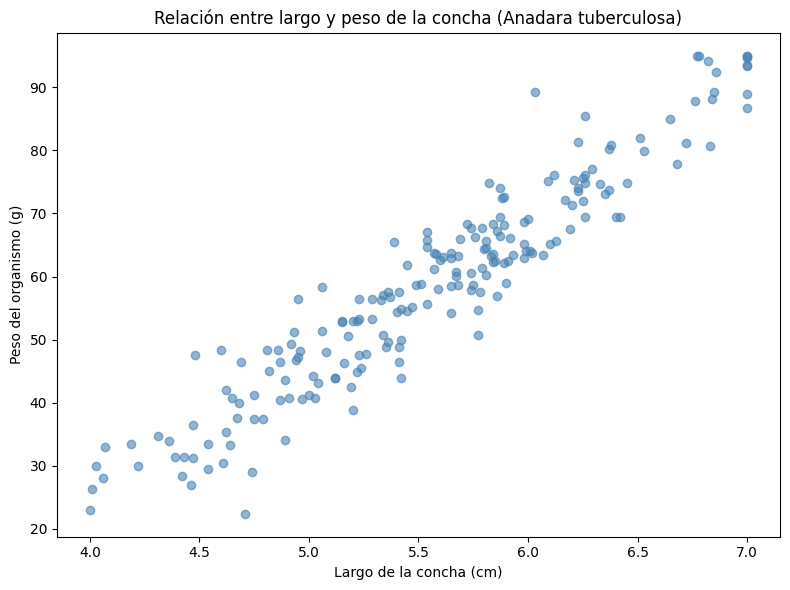

In [29]:
# ============================================================
# CELDA 4. SCATTERPLOT: LARGO VS. PESO
# ============================================================

# Creamos la figura.
plt.figure(figsize=(8, 6))

# Dibujamos la relación entre largo y peso.
plt.scatter(df["largo_cm"], df["peso_g"], alpha=0.6, color="steelblue")

# Añadimos título y etiquetas.
plt.title("Relación entre largo y peso de la concha (Anadara tuberculosa)")
plt.xlabel("Largo de la concha (cm)")
plt.ylabel("Peso del organismo (g)")

# Ajustamos el diseño y mostramos la figura.
plt.tight_layout()
plt.show()